In [1]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

In [2]:
conn = sqlite3.connect("../data/checking-logs.sqlite")

In [8]:
df1 = pd.read_sql(
    '''
        SELECT 
            c.uid, 
            COUNT(DISTINCT c.timestamp) AS num_commits,
            COUNT(DISTINCT p.datetime) AS pageviews
        FROM checker AS c
        INNER JOIN pageviews AS p ON c.uid = p.uid
        WHERE (
            c.uid LIKE 'user_%'
            AND c.labname != 'project1'
        )        
        GROUP BY c.uid
    ''',
    conn,
)
df1.head()

,uid,num_commits,pageviews
0,user_1,62,28
1,user_10,20,89
2,user_14,61,143
3,user_17,51,47
4,user_18,5,3


In [9]:
df2 = pd.read_sql(
    '''
        SELECT uid, AVG(diff) AS avg_diff
        FROM (
            SELECT uid, labname,
                (
                    CAST(julianday(timestamp) - julianday(deadlines, 'unixepoch') AS INTEGER) * 24
                ) AS diff
            FROM checker AS c
            INNER JOIN deadlines AS d ON c.labname = d.labs
            WHERE (
                c.status = 'ready'
                AND c.numTrials = 1
                AND c.uid LIKE 'user_%'
                AND c.labname != 'project1'
            )
            GROUP BY c.uid, c.labname
        )
        GROUP BY uid
    ''',
    conn
)
df2.head()

,uid,avg_diff
0,user_1,-57.6
1,user_10,-62.4
2,user_11,0.0
3,user_12,-78.0
4,user_13,-42.0


In [15]:
df = pd.merge(df1, df2, how='inner', on='uid')
print(df.shape)
df.head()

(11, 4)


,uid,num_commits,pageviews,avg_diff
0,user_1,62,28,-57.6
1,user_10,20,89,-62.4
2,user_14,61,143,-152.0
3,user_17,51,47,-52.8
4,user_18,5,3,0.0


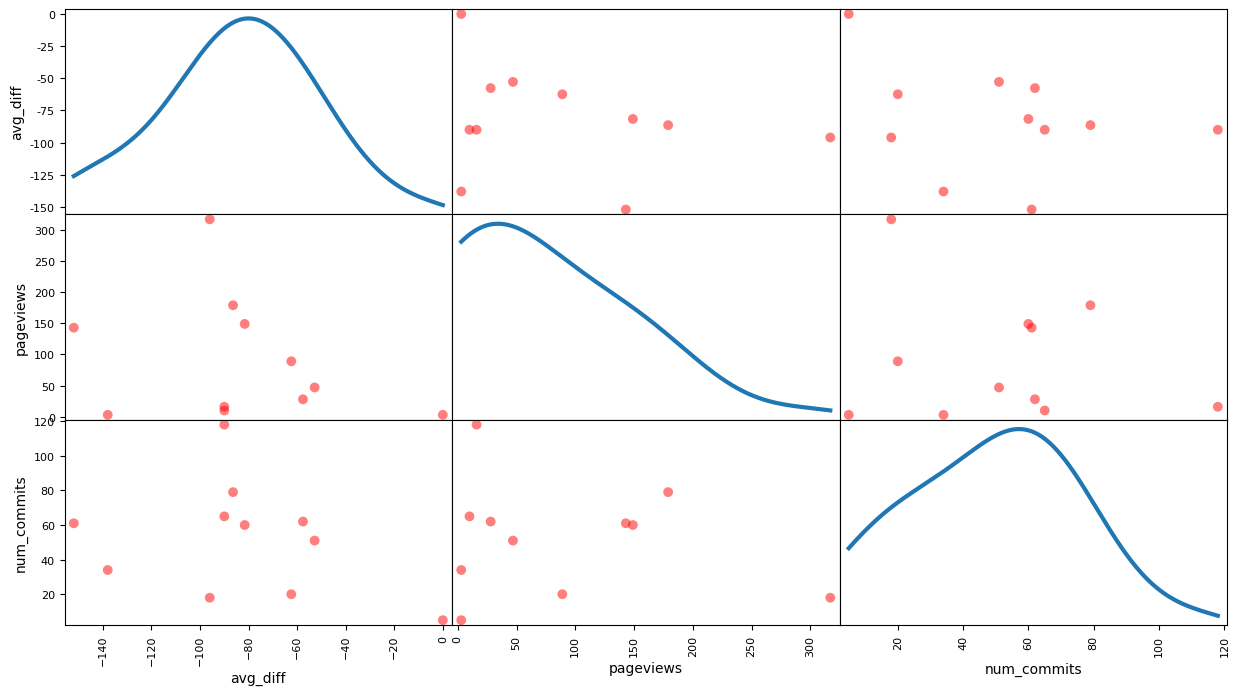

In [14]:
scatter_props = {
    'diagonal': 'kde',
    'figsize': (15, 8),
    'color': 'red',
    's': 200,
    'density_kwds': {
      'linewidth': 3,
    }
}

matrix = scatter_matrix(
  df[['avg_diff', 'pageviews', 'num_commits']],
  **scatter_props
)

- Can we say that if a user has a low number of pageviews then they likely have a low number of commits? No 
- Can we say that if a user has a low number of pageviews then they likely have a small average difference between the first commit and the lab deadline? No  
- Can we say that there are many users with a low number of commits and a few with a high number of commits? Yes  
- Can we say that there are many users with a small average difference and a few with a large average difference? No  

In [ ]:
conn.close()